<a class="anchor" id="0"></a>
# **Catégorisez automatiquement des questions**


## Contexte :

Stack Overflow est un site célèbre de questions-réponses liées au développement informatique.

Pour poser une question sur ce site, il faut entrer plusieurs tags afin de retrouver facilement la question par la suite. Pour les utilisateurs expérimentés, cela ne pose pas de problème, mais pour les nouveaux utilisateurs, il serait judicieux de suggérer quelques tags relatifs à la question posée.


## Mission :

Amateur de Stack Overflow, qui vous a souvent sauvé la mise, vous décidez d'aider la communauté en retour. Pour cela, vous développez un système de suggestion de tags pour le site. Celui-ci prendra la forme d’un algorithme de machine learning qui assignera automatiquement plusieurs tags pertinents à une question.

## Informations complémentaires :

Stack Overflow propose un outil d’export de données, "StackExchange Data Explorer", qui recense un grand nombre de données authentiques de la plateforme d’entraide. 
Voici la requête SQL utilisée pour obtenir notre fichier csv:

SELECT TOP 50000 Title, Body, Tags, Id
FROM Posts 
WHERE  Score > 50 AND AnswerCount > 5 AND LEN(Tags) - LEN(REPLACE(Tags, '<','')) >= 1
ORDER BY Score


# **Table des matières** <a class="anchor" id="0.1"></a>


- 1 [Préparation initiale dataset](#1)
  - 1.1 [Récupération du dataset et filtres de donnéest](#1.1)
  - 1.2 [Préparation de la métrique Hamming](#1.2)
  - 1.3 [Définition de la fonction de comparaison de modèle](#1.3)
  - 1.4 [Préparation multilabel target](#1.4)
- 2 [Bag of word - Tf-idf](#2)
    - 2.1 [Préparation sentences](#2.1)
    - 2.2 [Comparaison de différents modèles](#2.2)
- 3 [Word2Vec](#3)
    - 3.1 [Création du modèle Word2Vec](#3.1)
    - 3.2 [Création de la matrice d'embedding](#3.2)
    - 3.3 [Création du modèle d'embedding](#3.3)   
    - 3.4 [Comparaison de différents modèles](#3.4)
- 4 [BERT](#4)
    - 4.1 [Création des fonctions de feature engineering](#4.1)
    - 4.2 [Comparaison de différents modèles](#4.2)
- 5 [USE - Universal Sentence Encoder](#5)
    - 5.1 [Création des fonctions de feature engineering](#5.1)
    - 5.2 [Comparaison de différents modèles](#5.2)
- 6 [Comparaison des différents embeddings](#6)



<a class="anchor" id="1"></a>
# **1. Préparation initiale dataset** 

[Table des matières](#0.1)

## <a class="anchor" id="1.1"></a>
# **1.1 Récupération du dataset et filtres de données** 

[Table des matières](#0.1)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer


from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import hamming_loss,make_scorer
from sklearn.model_selection import GridSearchCV

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')


import pickle
import time
import logging

logging.disable(logging.WARNING) # disable WARNING, INFO and DEBUG logging everywhere

from bs4 import BeautifulSoup 

[nltk_data] Downloading package stopwords to /home/vortax/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/vortax/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/vortax/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/vortax/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [74]:
Results_score_tfidif = pd.read_csv('Results_score_tfidf.csv',index_col='Unnamed: 0')
Results_score_w2v  = pd.read_csv('Results_score_w2v.csv',index_col='Unnamed: 0')
Results_score_bert  = pd.read_csv('Results_score_bert.csv',index_col='Unnamed: 0')
Results_score_use  = pd.read_csv('Results_score_use.csv',index_col='Unnamed: 0')

In [21]:
data_T0 = pd.read_json('tags_learning.json')
data_T0

,Title,Body,Id,Len_tags,New_len_tags,Tags,Title_bow_lem,Text_bow_lem,Length_bow_title,Length_bow_text,Text_Title
12683,Reading integers from binary file in Python,"<p>I'm trying to read a <a href=""http://en.wik...",1163459,4,1,[python],integer file,file python byte bmp firm byte file size value...,2,17,integer file file python byte bmp firm byte fi...
25667,"""usort"" a Doctrine\Common\Collections\ArrayCol...",<p>In various cases I need to sort a <code>Doc...,16705425,3,1,[php],usort collection arraycollection,case property object method way php array wond...,3,11,usort collection arraycollection case property...
26912,What is the difference between char a[] = ?str...,"<p>As the heading says, What is the difference...",9460260,2,1,[c++],difference char string char string,heading difference question interview statemen...,5,9,difference char string char string heading dif...
1047,Making a short alias for document.querySelecto...,<p>I'm running <code>document.querySelectorAll...,13383886,2,1,[javascript],alia document,alia work alia work,2,4,alia document alia work alia work
17164,Where is android_sdk_root? and how do I set it.?,<p>I set the android_sdk_home variable so that...,29391511,1,1,[android],,variable application error win installation st...,0,16,variable application error win installation s...
...,...,...,...,...,...,...,...,...,...,...,...
8535,List<String> to ArrayList<String> conversion i...,<p>I have a following method...which actually ...,13134983,3,1,[java],list string arraylist string conversion issue,method list sentence sentence word list hashma...,6,16,list string arraylist string conversion issue ...
4627,React 18 TypeScript children FC,<p>I upgraded to React 18 and things compiled ...,71788254,3,2,"[javascript, reactjs]",child,thing today component child error child prop i...,1,15,child thing today component child error child ...
9867,Why was p[:] designed to work differently in t...,"<pre><code>p = [1,2,3]\nprint(p) # [1, 2, 3]\n...",56782148,3,1,[python],work situation,confirm way situation code copy feel list novi...,2,16,work situation confirm way situation code copy...
19867,Mocking EF core dbcontext and dbset,"<p>I am using ASP.NET Core 2.2, EF Core and MO...",54219742,5,1,[c#],ef dbset,asp core ef core moq test error message system...,2,19,ef dbset asp core ef core moq test error messa...


In [23]:
def text_extract(row) : 
    blocklist = [  'code','pre','a']
    text_elements = [t for t in BeautifulSoup(row).find_all(
    string=True) if t.parent.name not in blocklist and t!='\n']
    text = str()
    for i in range(len(text_elements)) : 
        text = text+text_elements[i]
    return text

In [24]:
data_T0['Body_clean'] = data_T0['Body'].apply(text_extract)
data_T0['Title_Text_clean'] = data_T0['Title']+ str(' ')+data_T0['Body_clean']

In [25]:
data_T = data_T0.drop(['Id', 'Body','Len_tags', 'New_len_tags'],axis=1)
data_T.head()

,Title,Tags,Title_bow_lem,Text_bow_lem,Length_bow_title,Length_bow_text,Text_Title,Body_clean,Title_Text_clean
12683,Reading integers from binary file in Python,[python],integer file,file python byte bmp firm byte file size value...,2,17,integer file file python byte bmp firm byte fi...,I'm trying to read a file in Python. I know t...,Reading integers from binary file in Python I'...
25667,"""usort"" a Doctrine\Common\Collections\ArrayCol...",[php],usort collection arraycollection,case property object method way php array wond...,3,11,usort collection arraycollection case property...,In various cases I need to sort a according t...,"""usort"" a Doctrine\Common\Collections\ArrayCol..."
26912,What is the difference between char a[] = ?str...,[c++],difference char string char string,heading difference question interview statemen...,5,9,difference char string char string heading dif...,"As the heading says, What is the difference be...",What is the difference between char a[] = ?str...
1047,Making a short alias for document.querySelecto...,[javascript],alia document,alia work alia work,2,4,alia document alia work alia work,"I'm running frequently, and would like a shor...",Making a short alias for document.querySelecto...
17164,Where is android_sdk_root? and how do I set it.?,[android],,variable application error win installation st...,0,16,variable application error win installation s...,I set the android_sdk_home variable so that my...,Where is android_sdk_root? and how do I set it...


In [26]:
# Tokenizer
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

def tokenizer_fct(sentence) :
    # print(sentence)
    sentence_clean = sentence.replace('-', ' ').replace('+', ' ').replace('/', ' ').replace(
        '#', ' ').replace('\\', ' ').replace('[', '').replace(']','').replace('"',"").replace('.'," ").replace("'"," ").replace('=',' ').replace('?',' ').replace('-',' ').replace('+',' ')
    word_tokens = word_tokenize(sentence_clean)
    return word_tokens

# lower case et alpha
def lower_start_fct(list_words) :
    lw = [w.lower() for w in list_words if (not w.startswith("@")) 
    #                                   and (not w.startswith("#"))
                                       and (not w.startswith("http"))]
    return lw


# Fonction de préparation du texte pour le Deep learning (USE et BERT)
def transform_dl_fct(desc_text) :
    word_tokens = tokenizer_fct(desc_text)
#    sw = stop_word_filter_fct(word_tokens)
    lw = lower_start_fct(word_tokens)
    # lem_w = lemma_fct(lw)    
    transf_desc_text = ' '.join(lw)
    return transf_desc_text

<a class="anchor" id="1.2"></a>
# **1.2 Préparation de la métrique Hamming** 

[Table des matières](#0.1) 

In [39]:


def hamming_score(y_true, y_pred, normalize=True, sample_weight=None):
    acc_list = []
    for i in range(y_true.shape[0]):
        set_true = set( np.where(y_true[i])[0] )
        set_pred = set( np.where(y_pred[i])[0] )
        tmp_a = None
        if len(set_true) == 0 and len(set_pred) == 0:
            tmp_a = 1
        else:
            tmp_a = len(set_true.intersection(set_pred))/float(len(set_true.union(set_pred)) )
        acc_list.append(tmp_a)
    return np.mean(acc_list)

def print_score(y_pred, clf):
    print("Clf: ", clf.__class__.__name__)
    print("Hamming loss: {}".format(hamming_loss(y_pred, y_test)))
    print("Hamming score: {}".format(hamming_score(y_pred, y_test)))
    print("---")   

<a class="anchor" id="1.3"></a>
# **1.3 Définition de la fonction de comparaison de modèle** 

[Table des matières](#0.1) 

In [73]:
def model_comparaison(feature,name) : 
    svc = LinearSVC()
    sgd = SGDClassifier()
    lr = LogisticRegression()
    rfc = RandomForestClassifier()
    index = ['SVC','SGD','Logistic','RandomForestClassifier']
    Results_score = pd.DataFrame(columns=['mean_train_score','mean_test_score','params'],index= index)
    param_grid = {
                  0 : {'estimator__penalty': ['l1','l2']},
                  1 :  {'estimator__penalty': ['l1','l2'],
                        'estimator__alpha': [1e-3,1e-2,1e-1]},
                  2 :  {'estimator__penalty': ['l1','l2']},
                  3 : {'estimator__n_estimators' : [20,50],
                       'estimator__criterion':['gini'], 
                       'estimator__max_depth': [10]}
                 }
    hamming = make_scorer(hamming_score)
    for i,classifier in enumerate([svc, sgd, lr, rfc]):
        clf = OneVsRestClassifier(classifier)
        clf_cv =GridSearchCV(clf,param_grid=param_grid[i],cv=4,scoring=hamming,return_train_score=True)
        clf_cv.fit(feature, Y)
        Cv_df = pd.DataFrame(clf_cv.cv_results_)
        Results_score.loc[index[i]] = Cv_df.loc[clf_cv.best_index_,['mean_train_score','mean_test_score','params']]
    Results_score.to_csv('Results_score_'+str(name)+'.csv')
    return Results_score

<a class="anchor" id="1.4"></a>
# **1.4 Préparation multilabel target** 

[Table des matières](#0.1) 

In [ ]:
multilabel_binarizer = MultiLabelBinarizer()
multilabel_binarizer.fit(data_T.Tags)
Y = multilabel_binarizer.transform(data_T.Tags)

<a class="anchor" id="2"></a>
# **2. Bag of word - Tf-idf** 

[Table des matières](#0.1) 

<a class="anchor" id="2.1"></a>
# **2.1 Préparation sentences** 

[Table des matières](#0.1) 

In [31]:
# création du bag of words (CountVectorizer et Tf-idf)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

cvect = CountVectorizer(stop_words='english', max_df=0.95, min_df=1)
ctf = TfidfVectorizer(max_df=0.5, min_df=5, stop_words="english",
    max_features = 1000)


feat = 'Text_Title'
cv_fit = cvect.fit(data_T[feat])
ctf_fit = ctf.fit(data_T[feat])

cv_transform = cvect.transform(data_T[feat])  
ctf_transform = ctf.transform(data_T[feat])  

<a class="anchor" id="2.2"></a>
# **2.2 Comparaison de différents modèles** 

[Table des matières](#0.1) 

In [40]:
Results_score_tfidf = model_comparaison(ctf_transform,'tfidf')

/home/vortax/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
4 fits failed out of a total of 8.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vortax/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vortax/anaconda3/lib/python3.9/site-packages/sklearn/multiclass.py", line 337, in fit
    self.estimators_ = Parallel(n_jobs=self.n_jobs)(
  File "/home/vortax/anaconda3/lib/python3.9/site-packages/joblib/parallel.py", line 1085, in __call__
    if self.dispatch_one_batch(iterator):

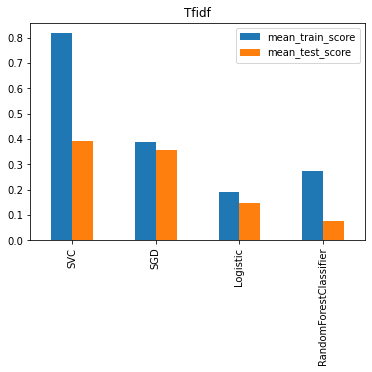

In [36]:
Results_score_tfidf.plot.bar()
plt.title('Tfidf')
plt.show()

<a class="anchor" id="3"></a>
# **3. Word2Vec** 

[Table des matières](#0.1)  

In [11]:
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import gensim

<a class="anchor" id="3.1"></a>
# **3.1 Création du modèle Word2Vec** 

[Table des matières](#0.1)  

In [12]:
w2v_size=300
w2v_window=5
w2v_min_count=1
w2v_epochs=100
maxlen = (data_T['Length_bow_title']+data_T['Length_bow_text']).max() +2
sentences = data_T['Text_Title'].to_list()
sentences = [gensim.utils.simple_preprocess(text) for text in sentences]

In [13]:
# Création et entraînement du modèle Word2Vec

print("Build & train Word2Vec model ...")
w2v_model = gensim.models.Word2Vec(min_count=w2v_min_count, window=w2v_window,
                                                vector_size=w2v_size,
                                                seed=42,
                                                workers=1)
#                                                workers=multiprocessing.cpu_count())
w2v_model.build_vocab(sentences)
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=w2v_epochs)
model_vectors = w2v_model.wv
w2v_words = model_vectors.index_to_key
print("Vocabulary size: %i" % len(w2v_words))
print("Word2Vec trained")

Build & train Word2Vec model ...
Vocabulary size: 4331
Word2Vec trained


In [14]:
# Préparation des sentences (tokenization)

print("Fit Tokenizer ...")
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)
x_sentences = pad_sequences(tokenizer.texts_to_sequences(sentences),
                                                     maxlen=maxlen,
                                                     padding='post') 
                                                   
num_words = len(tokenizer.word_index) + 1
print("Number of unique words: %i" % num_words)

Fit Tokenizer ...
Number of unique words: 4332


<a class="anchor" id="3.2"></a>
# **3.2 Création de la matrice d'embedding** 

[Table des matières](#0.1)  

In [15]:
# Création de la matrice d'embedding

print("Create Embedding matrix ...")
w2v_size = 300
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, w2v_size))
i=0
j=0
    
for word, idx in word_index.items():
    i +=1
    if word in w2v_words:
        j +=1
        embedding_vector = model_vectors[word]
        if embedding_vector is not None:
            embedding_matrix[idx] = model_vectors[word]
            
word_rate = np.round(j/i,4)
print("Word embedding rate : ", word_rate)
print("Embedding matrix: %s" % str(embedding_matrix.shape))

Create Embedding matrix ...
Word embedding rate :  1.0
Embedding matrix: (4332, 300)


In [16]:
tokenizer.word_index

{'code': 1,
 'file': 2,
 'way': 3,
 'error': 4,
 'value': 5,
 'method': 6,
 'string': 7,
 'app': 8,
 'problem': 9,
 'class': 10,
 'example': 11,
 'function': 12,
 'user': 13,
 'time': 14,
 'object': 15,
 'project': 16,
 'array': 17,
 'python': 18,
 'datum': 19,
 'list': 20,
 'application': 21,
 'type': 22,
 'text': 23,
 'line': 24,
 'server': 25,
 'don': 26,
 'image': 27,
 'test': 28,
 'javascript': 29,
 'element': 30,
 'question': 31,
 'solution': 32,
 'version': 33,
 'table': 34,
 'window': 35,
 'number': 36,
 'field': 37,
 'page': 38,
 'android': 39,
 'property': 40,
 'name': 41,
 'system': 42,
 'command': 43,
 'view': 44,
 'git': 45,
 'issue': 46,
 'case': 47,
 'html': 48,
 'work': 49,
 'result': 50,
 'idea': 51,
 'database': 52,
 'php': 53,
 'thing': 54,
 'browser': 55,
 'column': 56,
 'thank': 57,
 'library': 58,
 'button': 59,
 'variable': 60,
 'size': 61,
 'edit': 62,
 'use': 63,
 'item': 64,
 'doesn': 65,
 'exception': 66,
 'message': 67,
 'web': 68,
 'date': 69,
 'css': 70,
 

In [17]:
 w2v_words

['code',
 'file',
 'way',
 'error',
 'value',
 'method',
 'string',
 'app',
 'problem',
 'class',
 'example',
 'function',
 'user',
 'time',
 'object',
 'project',
 'array',
 'python',
 'datum',
 'list',
 'application',
 'type',
 'text',
 'line',
 'server',
 'don',
 'image',
 'test',
 'javascript',
 'element',
 'solution',
 'version',
 'question',
 'table',
 'window',
 'number',
 'page',
 'field',
 'android',
 'property',
 'name',
 'system',
 'view',
 'command',
 'git',
 'issue',
 'case',
 'html',
 'work',
 'result',
 'idea',
 'database',
 'php',
 'thing',
 'browser',
 'column',
 'thank',
 'library',
 'button',
 'variable',
 'edit',
 'size',
 'item',
 'use',
 'doesn',
 'exception',
 'message',
 'web',
 'date',
 'css',
 'json',
 'directory',
 'input',
 'query',
 'studio',
 'request',
 'java',
 'script',
 'output',
 'answer',
 'default',
 'event',
 'jquery',
 'service',
 'form',
 'screen',
 'folder',
 'character',
 'bit',
 'package',
 'height',
 'model',
 'option',
 'io',
 'module',
 'pr

<a class="anchor" id="3.3"></a>
# **3.3 Création du modèle d'embedding** 

[Table des matières](#0.1)  

In [18]:
input=Input(shape=(len(x_sentences),maxlen),dtype='float64')
word_input=Input(shape=(maxlen,),dtype='float64')  
word_embedding=Embedding(input_dim=vocab_size,
                         output_dim=w2v_size,
                         weights = [embedding_matrix],
                         input_length=maxlen)(word_input)
word_vec=GlobalAveragePooling1D()(word_embedding)  
embed_model = Model([word_input],word_vec)

embed_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 279)]             0         
                                                                 
 embedding (Embedding)       (None, 279, 300)          1299600   
                                                                 
 global_average_pooling1d (G  (None, 300)              0         
 lobalAveragePooling1D)                                          
                                                                 
Total params: 1,299,600
Trainable params: 1,299,600
Non-trainable params: 0
_________________________________________________________________


<a class="anchor" id="3.4"></a>
# **3.4 Comparaison de différents modèles** 

[Table des matières](#0.1) 

In [19]:
embeddings = embed_model.predict(x_sentences)
embeddings.shape

60/60 [==============================] - 1s 6ms/step


(1902, 300)

In [20]:
x_sentences

array([[ 202,    2,    2, ...,    0,    0,    0],
       [1676,  194, 1677, ...,    0,    0,    0],
       [ 105,  434,    7, ...,    0,    0,    0],
       ...,
       [  49,  399, 4326, ...,    0,    0,    0],
       [1037, 2296,  198, ...,    0,    0,    0],
       [ 324,   31, 4329, ...,    0,    0,    0]], dtype=int32)

In [28]:
Results_score_w2v = model_comparaison(embeddings,'Word2Vec')

/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 2 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 7 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 8 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 2 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 7 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 8 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 2 is present in all training examples.
  warnings.warn(
/usr/local/li

In [ ]:
Results_score_w2v.plot().bar()
plt.title('Word2Vec')
plt.show()

<a class="anchor" id="4"></a>
# **4. BERT** 

[Table des matières](#0.1)  

In [ ]:
Y=Y[0:-2]

In [ ]:
import tensorflow as tf
# import tensorflow_hub as hub
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
! pip install transformers
# Bert
import os
import transformers
from transformers import *

os.environ["TF_KERAS"]='1'

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 42.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 25.3 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/transformers/generation_utils.py:24: FutureWarning: Importing `GenerationMixin` from `src/transformers/generation_utils.py` is deprecated and will be removed in Transformers v5. Import as `from transformers import GenerationMixin` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation_tf_utils.py:24: FutureWarning: Importing `TFGenerationMixin` from `src/transformers/generation_tf_utils.py` is deprecated and will be removed in Transformers v5. Import as `from transformers import TFGenerationMixin` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/generation_flax_utils.py:24: FutureWarning: Importing `FlaxGenerationMixin` from `src/transformers/generation_flax_utils.py` is deprecated and will be removed in Transformers v5. Import as `from transformers import FlaxGenerationMixin` instead.
  warnings.warn(


In [ ]:
print(tf.__version__)
print(tensorflow.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

2.12.0
2.12.0
Num GPUs Available:  0
True


<a class="anchor" id="4.1"></a>
# **4.1 Création des fonctions de feature engineering** 

[Table des matières](#0.1)

In [ ]:
# Fonction de préparation des sentences
def bert_inp_fct(sentences, bert_tokenizer, max_length) :
    input_ids=[]
    token_type_ids = []
    attention_mask=[]
    bert_inp_tot = []

    for sent in sentences:
        bert_inp = bert_tokenizer.encode_plus(sent,
                                              add_special_tokens = True,
                                              max_length = max_length,
                                              padding='max_length',
                                              return_attention_mask = True, 
                                              return_token_type_ids=True,
                                              truncation=True,
                                              return_tensors="tf")
    
        input_ids.append(bert_inp['input_ids'][0])
        token_type_ids.append(bert_inp['token_type_ids'][0])
        attention_mask.append(bert_inp['attention_mask'][0])
        bert_inp_tot.append((bert_inp['input_ids'][0], 
                             bert_inp['token_type_ids'][0], 
                             bert_inp['attention_mask'][0]))

    input_ids = np.asarray(input_ids)
    token_type_ids = np.asarray(token_type_ids)
    attention_mask = np.array(attention_mask)
    
    return input_ids, token_type_ids, attention_mask, bert_inp_tot
    

# Fonction de création des features
def feature_BERT_fct(model, model_type, sentences, max_length, b_size, mode='HF') :
    batch_size = b_size
    batch_size_pred = b_size
    bert_tokenizer = AutoTokenizer.from_pretrained(model_type)
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        input_ids, token_type_ids, attention_mask, bert_inp_tot = bert_inp_fct(sentences[idx:idx+batch_size], 
                                                                      bert_tokenizer, max_length)
        
        if mode=='HF' :    # Bert HuggingFace
            outputs = model.predict([input_ids, attention_mask, token_type_ids], batch_size=batch_size_pred)
            last_hidden_states = outputs.last_hidden_state

        if mode=='TFhub' : # Bert Tensorflow Hub
            text_preprocessed = {"input_word_ids" : input_ids, 
                                 "input_mask" : attention_mask, 
                                 "input_type_ids" : token_type_ids}
            outputs = model(text_preprocessed)
            last_hidden_states = outputs['sequence_output']
             
        if step ==0 :
            last_hidden_states_tot = last_hidden_states
            last_hidden_states_tot_0 = last_hidden_states
        else :
            last_hidden_states_tot = np.concatenate((last_hidden_states_tot,last_hidden_states))
    
    features_bert = np.array(last_hidden_states_tot).mean(axis=1)
    
    time2 = np.round(time.time() - time1,0)
    print("temps traitement : ", time2)
     
    return features_bert, last_hidden_states_tot

In [ ]:
max_length = 64
batch_size = 10
model_type = 'bert-base-uncased'
model = TFAutoModel.from_pretrained(model_type)
sentences = data_T['Text_Title'].to_list()
features_bert, last_hidden_states_tot = feature_BERT_fct(model, model_type, sentences, 
                                                         max_length, batch_size, mode='HF')

<a class="anchor" id="4.2"></a>
# **4.2 Comparaison de différents modèles** 

[Table des matières](#0.1) 

In [1]:
 Results_score_bert = model_comparaison(features_bert,'Bert')

In [ ]:
Results_score_bert.plot.bar()
plt.title('BERT')
plt.show()

<a class="anchor" id="5"></a>
# **5. USE - Universal Sentence Encoder** 

[Table des matières](#0.1)  

<a class="anchor" id="5.1"></a>
# **5.1 USE - Universal Sentence Encoder** 

[Table des matières](#0.1)  

In [ ]:
import tensorflow as tf
# import tensorflow_hub as hub
import tensorflow.keras
from tensorflow.keras import backend as K

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import metrics as kmetrics
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Bert
import transformers
from transformers import *

os.environ["TF_KERAS"]='1'

In [ ]:
print(tf.__version__)
print(tensorflow.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

2.12.0
2.12.0
Num GPUs Available:  0
True


In [ ]:
import tensorflow_hub as hub

embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

In [ ]:
def feature_USE_fct(sentences, b_size) :
    batch_size = b_size
    time1 = time.time()

    for step in range(len(sentences)//batch_size) :
        idx = step*batch_size
        feat = embed(sentences[idx:idx+batch_size])

        if step ==0 :
            features = feat
        else :
            features = np.concatenate((features,feat))

    time2 = np.round(time.time() - time1,0)
    return features

In [ ]:
batch_size = 10
sentences = data_T['Text_Title'].to_list()

In [ ]:
features_USE = feature_USE_fct(sentences, batch_size)

<a class="anchor" id="5.2"></a>
# **5.2 Comparaison de différents modèles** 

[Table des matières](#0.1)  

In [ ]:
 Results_score_use = model_comparaison(features_USE,'Use')


/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 2 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 7 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 8 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 2 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 7 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 8 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/multiclass.py:77: UserWarning: Label 2 is present in all training examples.
  warnings.warn(
/usr/local/li

In [ ]:
Results_score_use.plot.bar()
plt.title('USE')
plt.show()

,mean_train_score,mean_test_score,params
SVC,0.808671,0.671495,{'estimator__penalty': 'l2'}
SGD,0.722168,0.663587,"{'estimator__alpha': 0.001, 'estimator__penalt..."
Logistic,0.69873,0.650999,{'estimator__penalty': 'l2'}
RandomForestClassifier,0.968672,0.620224,"{'estimator__criterion': 'gini', 'estimator__m..."


<a class="anchor" id="6"></a>
# **6. Comparaison des différents embeddings** 

[Table des matières](#0.1)  

In [71]:
list_embeddings = ['tfidf','w2v','bert','use']
list_result = [Results_score_tfidf,Results_score_w2v,Results_score_bert,Results_score_use]
test = pd.concat([list_result[i].loc['SVC'] for i in range(len(list_result))],axis=1)
test.columns = list_embeddings

test = test.transpose()

<AxesSubplot:>

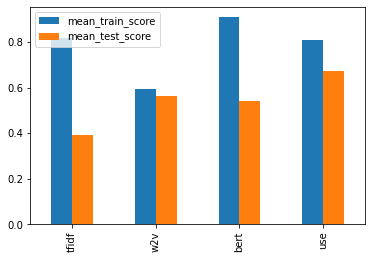

In [75]:
test.plot.bar()

[Retour en haut](#0)